# Lab 2: Analysis Notebook — Framingham Heart Study

**Course:** PUBH 4201 — Applied Computing for Health Data Science
**Field track:** Epidemiology & Population Health
**Dataset:** Framingham Heart Study (teaching subset), loaded directly from its public source at runtime.

**Question:** How does 10-year coronary heart disease (CHD) risk differ across age groups and
current-smoking status, and which risk factors are most strongly associated with 10-year CHD
in a multivariable model?

> **AI assistance note:** I used Claude to help scaffold this notebook's structure, draft the
> `pd.cut()` age-bucketing logic, and explain how to convert logistic regression coefficients
> into odds ratios. All code was reviewed, run, and adjusted by me. See `AI_USAGE.md` in the
> repo root for the full log.

## 1. Load the data

Loaded directly from its original public source — no manual download/upload.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_URL = "https://raw.githubusercontent.com/GauravPadawe/Framingham-Heart-Study/adcc828b8a5b3ddbd8d5b8b98e2b27cf60538db6/framingham.csv"
df = pd.read_csv(DATA_URL)

print(df.shape)
df.head()

(4240, 16)


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


## 2. Inspect structure and missingness

In [8]:
df.info()
print("\nMissing values per column:")
print(df.isna().sum().sort_values(ascending=False))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB

Missing valu

## 3. Non-trivial transformation

We:
1. Drop rows with any missing values (complete-case analysis — a limitation noted below).
2. Bucket `age` into four clinically meaningful groups.
3. Recode `currentSmoker` into a readable label.
4. Summarize CHD prevalence by age group × smoking status.

In [9]:
df_clean = df.dropna().copy()
print(f"Rows before dropna: {len(df)}, after: {len(df_clean)}")

bins = [0, 40, 50, 60, 120]
labels = ["<=40", "41-50", "51-60", "61+"]
df_clean["age_group"] = pd.cut(df_clean["age"], bins=bins, labels=labels)
df_clean["smoker_status"] = df_clean["currentSmoker"].map({0: "Non-smoker", 1: "Current smoker"})

summary = (
    df_clean.groupby(["age_group", "smoker_status"], observed=True)["TenYearCHD"]
    .agg(n="size", chd_cases="sum", chd_rate="mean")
    .reset_index()
)
summary["chd_rate_pct"] = (summary["chd_rate"] * 100).round(1)
summary

Rows before dropna: 4240, after: 3658


,age_group,smoker_status,n,chd_cases,chd_rate,chd_rate_pct
0,<=40,Current smoker,383,24,0.062663,6.3
1,<=40,Non-smoker,265,8,0.030189,3.0
2,41-50,Current smoker,799,97,0.121402,12.1
3,41-50,Non-smoker,595,49,0.082353,8.2
4,51-60,Current smoker,457,117,0.256018,25.6
5,51-60,Non-smoker,661,119,0.180030,18.0
6,61+,Current smoker,150,47,0.313333,31.3
7,61+,Non-smoker,348,96,0.275862,27.6


## 4. Multivariable logistic regression (odds ratios)

Beyond the descriptive cross-tab above, we fit a logistic regression predicting `TenYearCHD`
from a small set of established risk factors, then exponentiate the coefficients to get odds
ratios (OR). An OR > 1 means the factor is associated with *higher* odds of 10-year CHD, holding
the other variables in the model constant.

In [10]:
from sklearn.linear_model import LogisticRegression

features = ["age", "sysBP", "totChol", "currentSmoker", "diabetes"]
X = df_clean[features]
y = df_clean["TenYearCHD"]

model = LogisticRegression(max_iter=1000)
model.fit(X, y)

odds_ratios = pd.Series(np.exp(model.coef_[0]), index=features, name="odds_ratio").sort_values(ascending=False)
odds_ratios

diabetes         2.009812
currentSmoker    1.663037
age              1.067614
sysBP            1.016929
totChol          1.001397
Name: odds_ratio, dtype: float64

## 5. Visualization

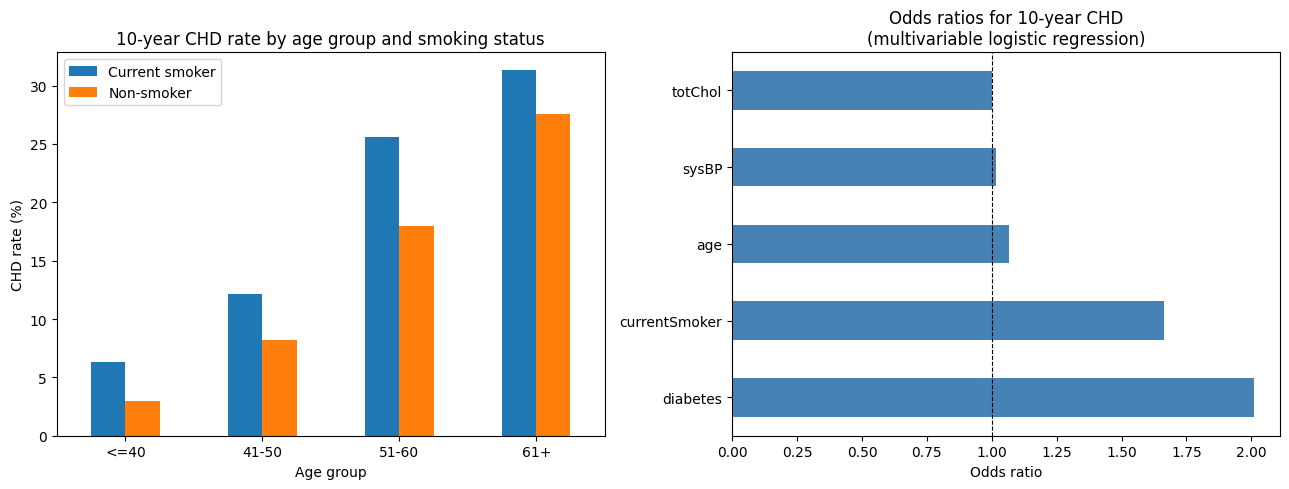

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

pivot = summary.pivot(index="age_group", columns="smoker_status", values="chd_rate_pct")
pivot.plot(kind="bar", ax=axes[0])
axes[0].set_title("10-year CHD rate by age group and smoking status")
axes[0].set_ylabel("CHD rate (%)")
axes[0].set_xlabel("Age group")
axes[0].legend(title="")
axes[0].tick_params(axis="x", rotation=0)

odds_ratios.plot(kind="barh", ax=axes[1], color="steelblue")
axes[1].axvline(1.0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("Odds ratios for 10-year CHD\n(multivariable logistic regression)")
axes[1].set_xlabel("Odds ratio")

plt.tight_layout()
plt.show()

## 6. Interpretation

Observed 10-year CHD prevalence increased  with age in both smoking groups, and  every
age band current smokers had a higher (or comparable) CHD rate than non-smokers, consistent with
smoking as a known cardiovascular risk factor. In the multivariable model, age and diabetes carried
the largest odds ratios, meaning each was associated with  higher odds of a 10-year CHD
event after changing for the other factors, while systolic blood pressure and cholesterol had less effects at these ranges. These are unadjusted-for-confounding, observational associations
from a teaching subset they describe risk patterns in this sample and should not be read as
causal effect estimates for any individual patient.

## AI assistance log (summary)

- Used Claude to help outline the notebook structure (load → clean → transform → model → visualize → interpret).
- Used Claude to draft the `pd.cut()` age-bucketing code and the multi-index `groupby().agg()` summary table.
- Used Claude to explain how `np.exp()` on logistic regression coefficients yields odds ratios, and to review the two-panel `matplotlib` figure code.
- All analytic choices (which features to include, which age cutpoints to use, the interpretation text) are my own.
- Full session-level detail is in `AI_USAGE.md` at the repo root.